In [6]:
import pandas as pd

from email_outreach.experiment_utils.metric_loader import load_experiment_metrics
from email_outreach.ml.shallow_autoencoder.abstract_contextual_model import AbstractContextualModel
from email_outreach.utils.constants import ROOT_FOLDER
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def get_precisions_recalls(path: Path, quantiles=1 - np.linspace(start=0, stop=1, num=100)):
    experiments: list[list] = load_experiment_metrics(path)
    recalls: list[float] = []
    precisions: list[float] = []
    for experiment in experiments:
        recall, precision = AbstractContextualModel.calculate_recall_precision_at_quantiles(experiment,
                                                                                            quantiles=quantiles)[1:3]

        recalls.append(recall)
        precisions.append(precision)

    return recalls, precisions

In [8]:
def get_recalls_auc(path: Path):
    experiments: list[list] = load_experiment_metrics(path)
    recalls_auc: list[float] = []
    for experiment in experiments:
        recall_auc = AbstractContextualModel.calculate_partial_auc(experiment)
        recalls_auc.append(recall_auc)

    return recalls_auc

In [9]:
def delta_pct(lhs: np.ndarray, rhs: np.ndarray, decimals: int = 2 ) -> np.ndarray:
    return ((lhs-rhs)*100).round(decimals)

In [10]:
p_not_sent_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "p_not_sent_v3"

# imp_s_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "f_p_phi_plug_v3"

baseline_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "baseline_v2"

In [11]:
p_not_sent_recalls, p_not_sent_precisions = get_precisions_recalls(p_not_sent_path)
baseline_recalls, baseline_precisions = get_precisions_recalls(baseline_path)
# imp_s_recalls, imp_s_precisions = get_precisions_recalls(imp_s_path)

In [12]:
p_not_sent_recalls_auc = get_recalls_auc(p_not_sent_path)
baseline_recalls_auc = get_recalls_auc(baseline_path)
# imp_s_recalls_auc = get_recalls_auc(imp_s_path)

In [13]:
np.array(p_not_sent_recalls_auc).mean(), np.array(baseline_recalls_auc).mean()

(np.float64(0.899144121917513), np.float64(0.8937074946193079))

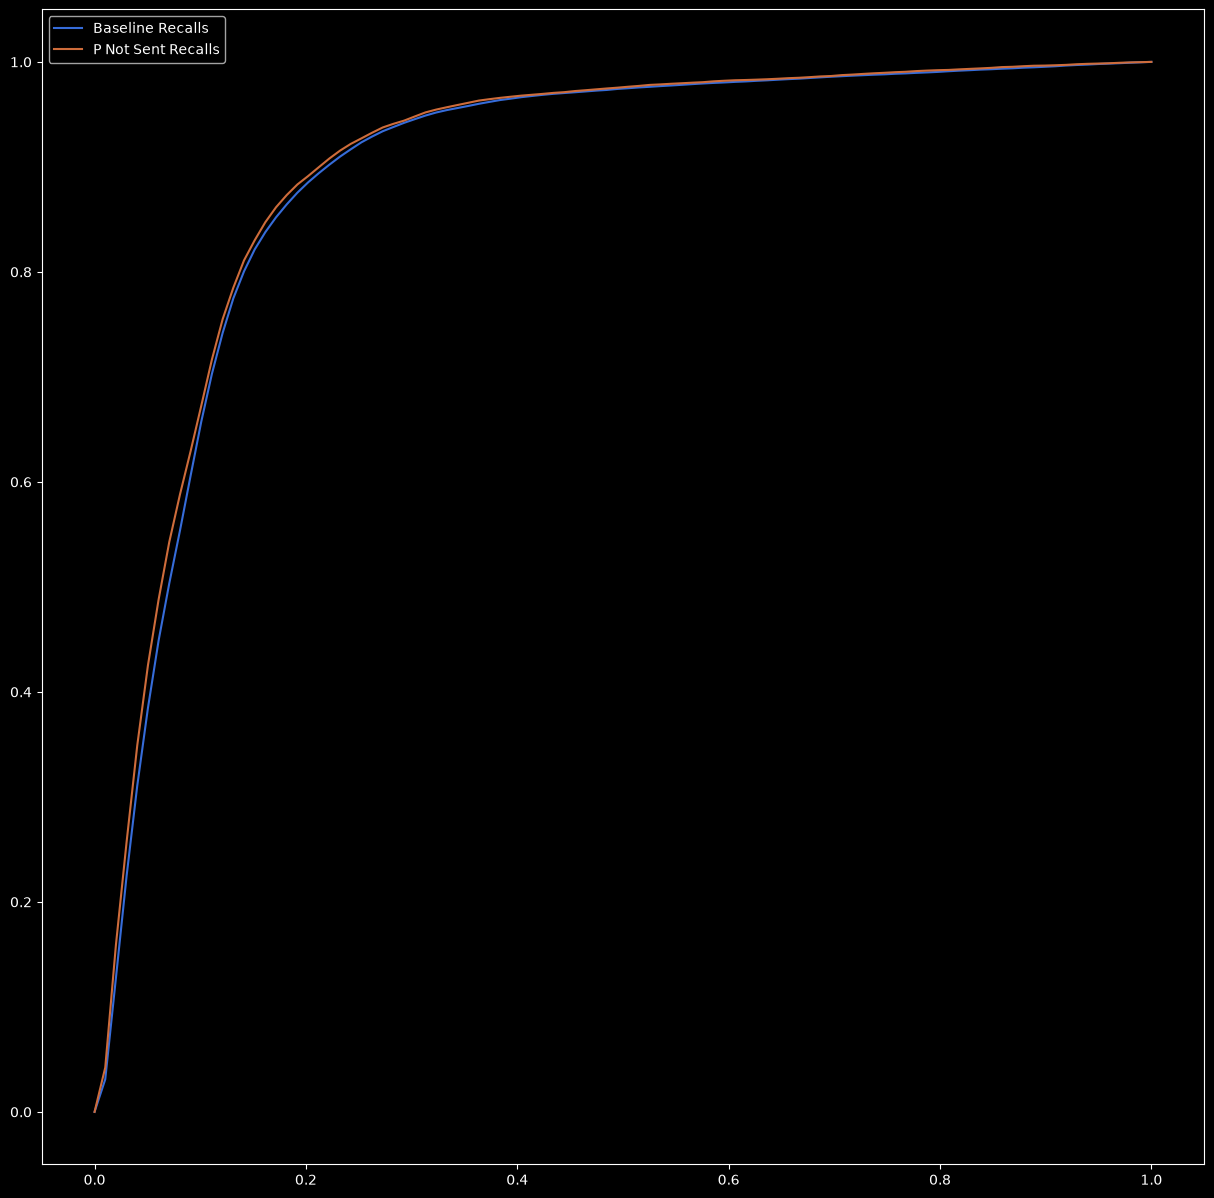

In [14]:
plt.figure(figsize=(15, 15))


plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0),
         label="Baseline Recalls")
plt.plot(np.linspace(start=0, stop=1, num=100), np.array(p_not_sent_recalls).mean(axis=0),
         label="P Not Sent Recalls")
# plt.plot(np.linspace(start=0, stop=1, num=100), np.array(imp_s_recalls).mean(axis=0),
#          label="Improved S Recalls")

plt.legend()